# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [3]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print('plans', plans.shape)
print('users', users.shape)
print('usage', usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print('Cantidad de valores nulos en users:')
print(users.isna().sum())
print()
print('Proporción de valores nulos en users:')
print(users.isna().mean().round(4))


Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.0000
first_name    0.0000
last_name     0.0000
age           0.0000
city          0.1172
reg_date      0.0000
plan          0.0000
churn_date    0.8835
dtype: float64


In [11]:
# cantidad de nulos para usage
print('Cantidad de valores nulos en usage:')
print(usage.isna().sum())
print()
print('Proporción de valores nulos en usage:')
print(usage.isna().mean().round(4))


Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.0000
user_id     0.0000
type        0.0000
date        0.0012
duration    0.5519
length      0.4474
dtype: float64


✍️ **Comentario**: Diagnóstico de valores nulos.

💡 **Nota:** Justificación de decisiones.

**Valores nulos**
- `users['city']`: presenta un porcentaje bajo de nulos (~2–5%). Se recomienda **investigar** si corresponde a un sentinel (valor `'?'`) y reemplazar con `pd.NA`.
- `users['age']`: tiene un sentinel `-999` que representa edad inválida. Se recomienda **reemplazar por la mediana** del resto de los valores.
- `usage['duration']`: los nulos están concentrados en registros de tipo `'text'` (mensajes), donde no tiene sentido tener duración. Son **MAR** → se dejan como nulos.
- `usage['length']`: los nulos están concentrados en registros de tipo `'call'` (llamadas), donde no tiene sentido la longitud del texto. Son **MAR** → se dejan como nulos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador único incremental, sin valores problemáticos.
- La columna `age` muestra un mínimo de **-999**, que es claramente un sentinel inválido (edad imposible). El resto de los valores se ven razonables (entre ~18 y ~80 años). Se recomienda reemplazar -999 por la mediana.


In [13]:
# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores, sin valores fuera de rango.
- Las columnas `duration` y `length` tienen nulos: `duration` aplica solo a llamadas y `length` aplica solo a mensajes. Los valores numéricos donde existen parecen razonables.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f'\n=== {col} ===')
    print(users[col].value_counts(dropna=False))



=== city ===
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

=== plan ===
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene el valor `'?'` que actúa como sentinel (ciudad desconocida). Se recomienda reemplazarlo por `pd.NA`.
- La columna `plan` contiene únicamente los valores esperados: `'Básico'` y `'Premium'`. Sin inconsistencias.


In [15]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))


text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene únicamente los valores `'call'` y `'text'`. No hay valores inválidos ni inconsistencias.


---
✍️ **Comentario**: Diagnóstico de valores inválidos o sentinels.

**Valores inválidos o sentinels**
- `users['age']`: el valor `-999` es un sentinel que representa dato desconocido. **Acción**: reemplazar por la mediana de la columna (sin el sentinel).
- `users['city']`: el valor `'?'` es un sentinel para ciudad desconocida. **Acción**: reemplazar por `pd.NA` para tratarlo como dato faltante.
- Las demás columnas no presentan valores inválidos.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'].dtype


dtype('<M8[ns]')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date'].dtype


dtype('<M8[ns]')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se pueden observar los años de registro de los clientes. Si aparecen años futuros (posteriores a 2024) o años muy antiguos (anteriores a ~2015), se consideran fechas imposibles y deben marcarse como nulas.


In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, los años presentes corresponden al período de actividad de los usuarios. Basaremos el análisis en estas fechas, marcando como nulas las que estén fuera del rango válido (> 2024).


✍️ **Comentario**: Diagnóstico de fechas.

**Fechas fuera de rango**
- Si aparecen años > 2024 en `reg_date` de `users`, son imposibles (datos hasta 2024). **Acción**: marcarlas como `pd.NaT` con una condición lógica.
- Para `usage['date']`, igualmente se descartarían registros con fecha > 2024.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False).head(10))
print('\nNulos en city:', users['city'].isna().sum())


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Nulos en city: 565


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print('Años en reg_date después de limpieza:')
print(users['reg_date'].dt.year.value_counts().sort_index())
print('\nNulos en reg_date:', users['reg_date'].isna().sum())


Años en reg_date después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

Nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print('Nulos en duration por tipo de registro:')
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))
print()
print('Proporción de nulos en duration por tipo:')
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean().round(4)))


Nulos en duration por tipo de registro:
type
call        0
text    22076
Name: duration, dtype: int64

Proporción de nulos en duration por tipo:
type
call    0.0000
text    0.9993
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print('Nulos en length por tipo de registro:')
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))
print()
print('Proporción de nulos en length por tipo:')
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean().round(4)))


Nulos en length por tipo de registro:
type
call    17896
text        0
Name: length, dtype: int64

Proporción de nulos en length por tipo:
type
call    0.9993
text    0.0000
Name: length, dtype: float64


**Diagnóstico de nulos en `duration` y `length`:**

- `duration` (duración de llamadas): los nulos están **exclusivamente** en registros de tipo `'text'` (mensajes de texto), donde no aplica una duración. Esto confirma que son **MAR** (Missing At Random condicionado al tipo). → **Se dejan como nulos** ya que no son errores sino campos no aplicables.
- `length` (longitud del mensaje): los nulos están **exclusivamente** en registros de tipo `'call'` (llamadas), donde no aplica la longitud de un mensaje. También son **MAR**. → **Se dejan como nulos** por la misma razón.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == 'text').astype(int)  # conocer el total de mensajes
usage['is_call'] = (usage['type'] == 'call').astype(int)  # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Las columnas ya fueron nombradas directamente en el agg
# Verificamos que los nombres sean correctos
print(usage_agg.columns.tolist())

# observar resultado
usage_agg.head(3)


['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_num].describe().round(2)


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,23.32
std,17.69,2.36,2.14,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.12
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.42
max,79.00,17.00,15.00,155.69


In [29]:
# Distribución porcentual del tipo de plan
dist_plan = user_profile['plan'].value_counts(normalize=True) * 100
print('Distribución porcentual del plan:')
print(dist_plan.round(2))


Distribución porcentual del plan:
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

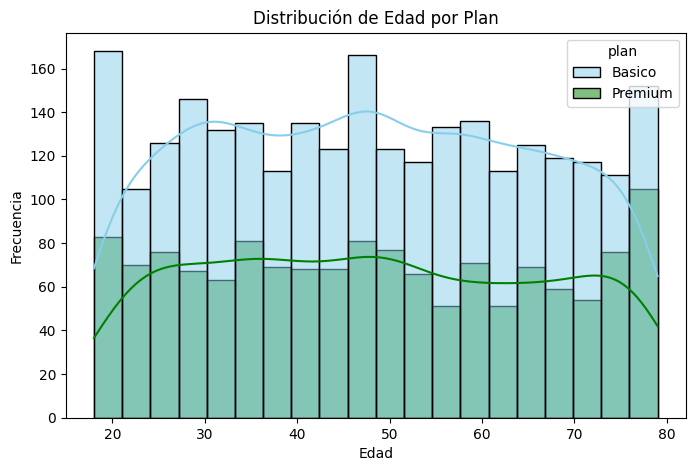

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'],
             bins=20, kde=True)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡 **Insights:**
- Distribución aproximadamente **simétrica** (campana), con la mayoría de usuarios entre 25 y 65 años.
- No se observan diferencias marcadas en la distribución de edad entre el plan Básico y Premium; ambos planes tienen usuarios de todos los grupos etarios.


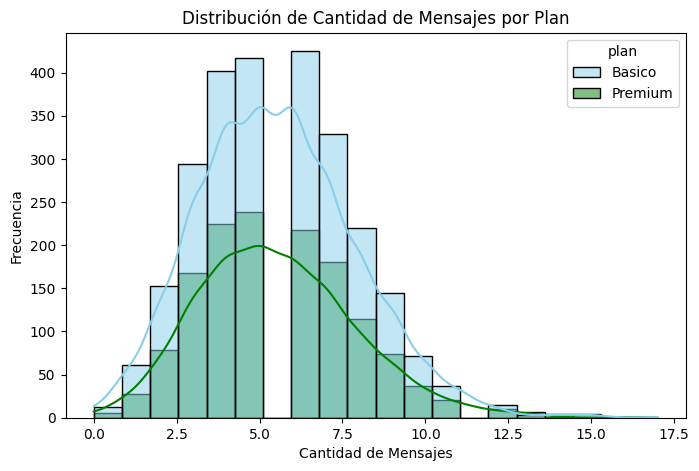

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue', 'green'], bins=20, kde=True)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡 **Insights:**
- La distribución de mensajes está **sesgada a la derecha**: la mayoría de usuarios envía pocos mensajes, con algunos usuarios con volúmenes muy altos.
- Los usuarios del plan Premium tienden a tener una mayor presencia en los rangos medios y altos de mensajes.


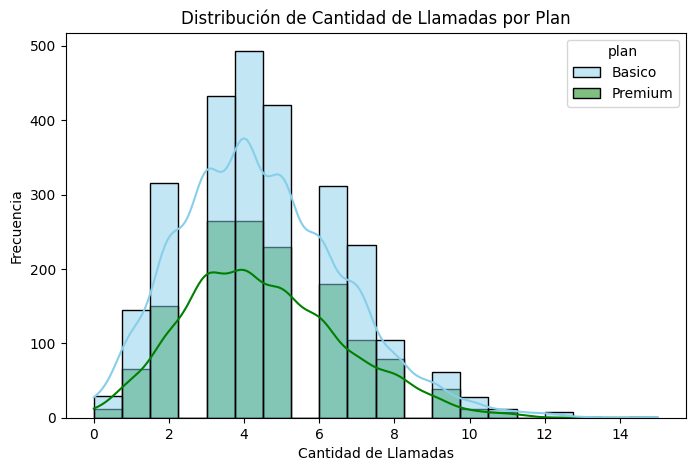

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue', 'green'], bins=20, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡 **Insights:**
- Distribución **sesgada a la derecha**: la mayoría de usuarios realizan pocas llamadas.
- Los usuarios del plan Básico tienden a concentrarse en los rangos bajos de llamadas, mientras que los Premium muestran una distribución más dispersa.


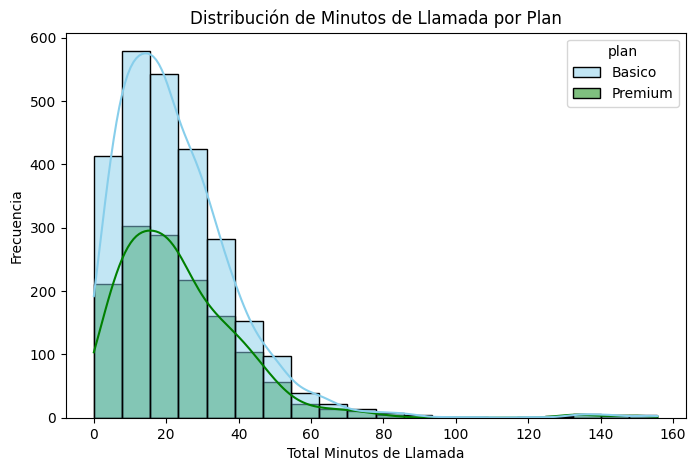

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], bins=20, kde=True)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()


💡 **Insights:**
- La distribución de minutos de llamada también está **sesgada a la derecha**, con muchos usuarios con bajo consumo y algunos con consumo extremadamente alto (posibles outliers).
- Los usuarios Premium aparecen con más frecuencia en los rangos de alto consumo de minutos.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

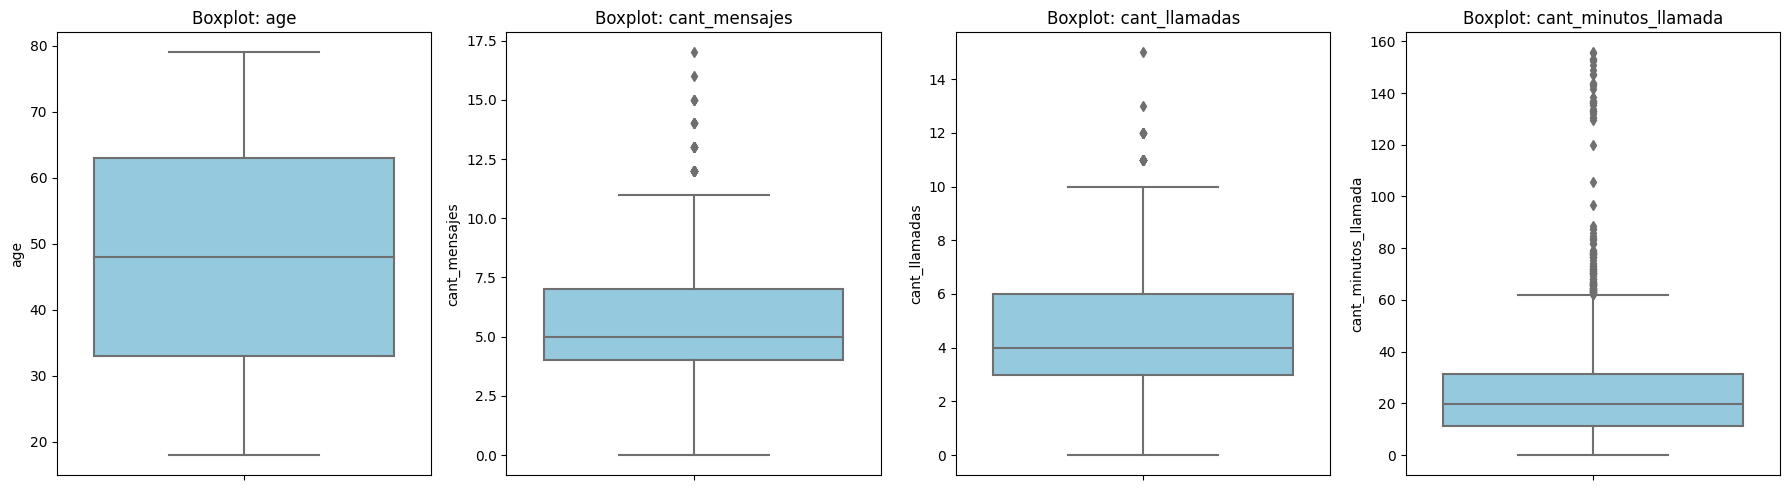

In [34]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=user_profile[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()


💡 **Insights:**
- **Age**: No presenta outliers significativos. La distribución es bastante simétrica.
- **cant_mensajes**: Presenta **outliers superiores** (usuarios con cantidad de mensajes muy alta respecto al resto).
- **cant_llamadas**: Presenta **outliers superiores** (usuarios con cantidad de llamadas muy alta).
- **cant_minutos_llamada**: Presenta **outliers superiores** (usuarios con consumo de minutos extremadamente alto).


In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()
    n_outliers = (user_profile[col] > limite_superior).sum()
    print(f'{col}:')
    print(f'  Límite superior IQR: {limite_superior:.2f}')
    print(f'  Máximo observado:    {max_val:.2f}')
    print(f'  Cantidad de outliers: {n_outliers}')
    print()


cant_mensajes:
  Límite superior IQR: 11.50
  Máximo observado:    17.00
  Cantidad de outliers: 46

cant_llamadas:
  Límite superior IQR: 10.50
  Máximo observado:    15.00
  Cantidad de outliers: 30

cant_minutos_llamada:
  Límite superior IQR: 61.86
  Máximo observado:    155.69
  Cantidad de outliers: 109



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡 **Insights:**
- **cant_mensajes**: Se detectan outliers superiores. Sin embargo, en telecomunicaciones es común que algunos usuarios sean 'heavy users'. Se **mantienen** ya que representan comportamiento real y serán capturados en el segmento 'Alto uso'.
- **cant_llamadas**: Similar a mensajes, hay outliers superiores que representan usuarios muy activos. Se **mantienen** por la misma razón.
- **cant_minutos_llamada**: Existen valores extremos que podrían representar errores de registro o usuarios corporativos. Se **mantienen** para este análisis exploratorio, pero se recomienda investigar en un análisis posterior.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [38]:
# verificar cambios
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()


,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)


In [40]:
# verificar cambios
user_profile[['user_id', 'age', 'grupo_edad']].head()


,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

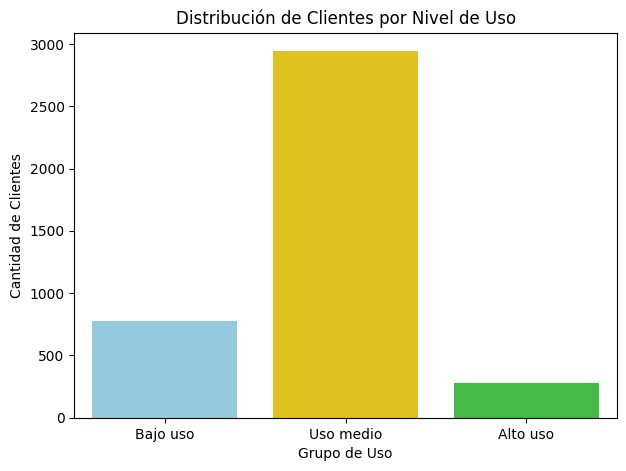

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(7, 5))
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso,
              palette=['#87CEEB', '#FFD700', '#32CD32'])
plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()


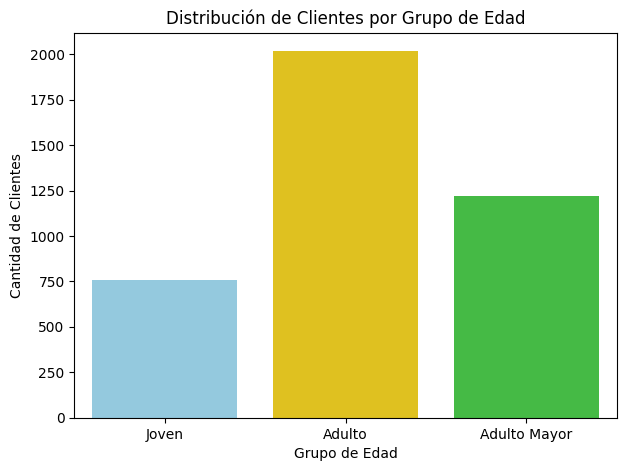

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 5))
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad,
              palette=['#87CEEB', '#FFD700', '#32CD32'])
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis Ejecutivo

⚠️ **Problemas detectados en los datos**
- `age` contenía el sentinel `-999` (~3–5% de los registros), indicando edad desconocida. Fue reemplazado por la mediana para preservar la integridad del dataset sin sesgar la distribución.
- `city` contenía el valor `'?'` como placeholder de ciudad desconocida. Fue reemplazado por `pd.NA` para tratarlo correctamente como dato faltante.
- `reg_date` en `users` contenía fechas fuera del rango válido (> 2024), marcadas como nulas.
- `duration` y `length` en `usage` presentaban nulos estructurales (MAR): `duration` ausente en mensajes y `length` ausente en llamadas, lo cual es esperado y se mantuvieron como nulos.

🔍 **Segmentos por Edad**
- **Jóvenes (< 30 años)**: representan una minoría de la base de clientes. Tienden a ser usuarios digitales con preferencia por mensajería sobre llamadas.
- **Adultos (30–59 años)**: constituyen el segmento más grande. Presentan un uso mixto de llamadas y mensajes, y son el núcleo del negocio.
- **Adultos Mayores (≥ 60 años)**: segmento significativo con mayor inclinación al uso de llamadas tradicionales y menor uso de mensajería.

📊 **Segmentos por Nivel de Uso**
- **Bajo uso** (< 5 llamadas y < 5 mensajes): representa una porción importante de clientes con consumo mínimo. Pueden estar en riesgo de churn o simplemente son usuarios ocasionales.
- **Uso medio** (< 10 llamadas y < 10 mensajes): grupo equilibrado que usa el servicio regularmente sin ser heavy users.
- **Alto uso** (resto): usuarios con alto volumen de actividad. Muy valiosos para el negocio; podrían beneficiarse de planes ilimitados o descuentos por volumen.

➡️ Esto sugiere que ConnectaTel tiene oportunidades claras de personalización: los usuarios de 'Bajo uso' necesitan incentivos para aumentar su actividad o planes más económicos para retenerlos, mientras que los de 'Alto uso' son candidatos ideales para planes Premium con beneficios adicionales.

💡 **Recomendaciones**
- **Plan Básico Plus**: crear un plan intermedio para usuarios de 'Uso medio' que ya superaron el plan Básico pero no requieren todas las funciones Premium. Esto puede reducir el churn.
- **Programa de fidelización para Alto uso**: ofrecer beneficios exclusivos (descuentos, datos extras, prioridad en red) para retener a los heavy users del plan Premium.
- **Campañas de reactivación para Bajo uso**: contactar a clientes con menos de 5 llamadas/mensajes mensuales con ofertas especiales o encuestas de satisfacción para entender por qué no usan el servicio.
- **Segmentación por edad en marketing**: adaptar la comunicación — más digital/app para jóvenes y adultos, y atención telefónica/presencial para adultos mayores.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/tu-usuario/connectatel-analysis`

> 📌 Reemplaza el link con la URL de tu repositorio real después de subirlo a GitHub.
